# STAT 207 Group Lab Assignment 5 - [10 total points]

## Sampling Distributions

<hr>

## <u>Lab Grading</u>:

Should we grade your submission?  If not, write the netID of the submission to be graded.  (Note: We will only grade one assignment per group, and we'll pick the first one that says we should grade that submission.  We will assign the same grade to all team members.)

*For example*, you might respond: **grade this submission** or **my submission is under netID jdeeke**

my submission is under colinhr3

If you said **my submission is under netID** above, we will not read any more of your lab submission.

If you said **grade this submission** above, who worked with you on this submission?  Write both their **names** and **netIDs**.  

<hr>

## <u>Purpose</u>:
You should work in groups of 2-3 on this report (not working in groups without permission will result in a point deduction). The purpose of this group lab assignment is to simulate sampling distributions and observe their properties.  
<hr>

## <u>Assignment Instructions</u>:

### Group Roles

Suggested and specified roles are provided below: 

#### Groups of 2

* **Driver**: This student will type the report.  While typing the report, you may be the one who is selecting the functions to apply to the data.
* **Navigator**: This student will guide the process of answering the question.  Specific ways to help may include: outlining the general steps needed to solve a question (providing the overview), locating examples within the course notes, and reviewing each line of code as it is typed.

#### Groups of 3

* **Driver**: This student will type the report.  They may also be the one to select the functions to apply to the data.
* **Navigator**: This student will guide the process of answering the question.  They may select the general approach to answering the question and/or a few steps to be completed along the way. 
* **Communicator**: This student will review the report (as it is typed) to ensure that it is clear and concise.  This student may also locate relevant examples within the course notes that may help complete the assignment.

<hr>

### Imports

In [15]:
#Run this
import pandas as pd                    # imports pandas and calls the imported version 'pd'
import matplotlib.pyplot as plt        # imports the package and calls it 'plt'
import seaborn as sns                  # imports the seaborn package with the imported name 'sns'
sns.set()  

## Case Study: Pokemon

The following dataset contains information about all current Pokemon, including those recently released in Generation 9 (2023).  6 Pokemon cards can be used in many battles, and we'd like to better understand characteristics of these six cards.

The variables in the data include:

- **Height**: height (m)
- **Weight**: weight (kg)
- **Type1**: the primary type of the Pokemon
- **Ability1**: the primary ability of the Pokemon
- **Ability_Hidden**: the hidden ability of the Pokemon, if one is present
- **Get_Rate**: the rate at which the Pokemon can be captured (higher = easier to capture)
- **HP**: the hit point, which is how much damage a Pokemon can sustain before fainting
- **Attack**: the damage a Pokemon can inflict with a physical move
- **Defense**: the damage a Pokemon receives when hit with a physical move
- **SP_Attack**: the damage a Pokemon can inflict with a special move
- **SP_Defense**: the damage a Pokemon receives when hit with a special move
- **Speed**: speed, which determines the order in which Pokemon can move
- **Total**: the sum of each of the base statistics (HP, Attack, Defense, SP_Attack, SP_Defense, and Speed).

There are other variables in the data, which you are allowed to use if you understand their provided values.  More information about this dataset can be found at https://www.kaggle.com/datasets/takamasakato/pokemon-all-status-data.

Run the code in the cell below to read in the data for this document.  The data is saved as `df` with this code.  

In [16]:
df = pd.read_csv('Pokedex_Ver9.csv')
df

,No,Branch_Code,Original_Name,Name,Generation,Height,Weight,Type1,Type2,Ability1,...,SP_Attack,SP_Defense,Speed,Total,E_HP,E_Attack,E_Defense,E_SP_Attack,E_SP_Defense,E_Speed
0,1,1_0,Bulbasaur,Bulbasaur,1,0.7,6.9,Grass,Poison,Overgrow,...,65,65,45,318,0,0,0,1,0,0
1,2,2_0,Ivysaur,Ivysaur,1,1.0,13.0,Grass,Poison,Overgrow,...,80,80,60,405,0,0,0,1,1,0
2,3,3_0,Venusaur,Venusaur,1,2.0,100.0,Grass,Poison,Overgrow,...,100,100,80,525,0,0,0,2,1,0
3,3,3_1,Venusaur,Mega Venusaur,1,2.4,155.5,Grass,Poison,Thick Fat,...,122,120,80,625,0,0,0,2,1,0
4,4,4_0,Charmander,Charmander,1,0.6,8.5,Fire,NaN,Blaze,...,60,50,65,309,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1198,1006,1006_0,Iron Valiant,Iron Valiant,9,1.4,35.0,Fairy,Fighting,Quark Drive,...,120,60,116,590,0,3,0,0,0,0
1199,1007,1007_0,Koraidon,Koraidon,9,2.5,303.0,Fighting,Dragon,Orichalcum Pulse,...,85,100,135,670,0,3,0,0,0,0
1200,1008,1008_0,Miraidon,Miraidon,9,3.5,240.0,Electric,Dragon,Hadron Engine,...,135,115,135,670,0,0,0,3,0,0
1201,1009,1009_0,Walking Wake,Walking Wake,9,3.5,280.0,Water,Dragon,Protosynthesis,...,125,83,109,590,0,0,0,3,0,0


In [17]:
df.columns

Index(['No', 'Branch_Code', 'Original_Name', 'Name', 'Generation', 'Height',
       'Weight', 'Type1', 'Type2', 'Ability1', 'Ability2', 'Ability_Hidden',
       'Color', 'Gender_Male', 'Gender_Female', 'Gender_Unknown', 'Egg_Steps',
       'Egg_Group1', 'Egg_Group2', 'Get_Rate', 'Base_Experience',
       'Experience_Type', 'Category', 'Mega_Evolution_Flag', 'Region_Form',
       'HP', 'Attack', 'Defense', 'SP_Attack', 'SP_Defense', 'Speed', 'Total',
       'E_HP', 'E_Attack', 'E_Defense', 'E_SP_Attack', 'E_SP_Defense',
       'E_Speed'],
      dtype='object')

## 1. [6 points] Understanding a Typical Set of Pokemon for Battle

In this first question, we will generate a sampling distribution for 6 Pokemon that could currently be used in a single battle.

**a)** To start, does the full data represent a population or a sample?

Population

**b)** Select one variable from this data and one statistic other than a mean that you will use to summarize this variable in each sample.

Speed, median

**c)** Generate one random sample of size 6 from the population.  Then, calculate the statistic for your variable of interest that you defined in **1b**.

In [18]:
sample = df.sample(n=6)

median_speed_sample = sample['Speed'].median()
print(f"Median Speed of the sample: {median_speed_sample}")

Median Speed of the sample: 82.5


**d)** Repeat this process for multiple repetitions, generating a sampling distribution for your statistic of interest.

In [21]:
n_repetitions = 100

median_speeds = []

for i in range(n_repetitions):
    sample = df.sample(n=6)
    median_speed = sample['Speed'].median()
    median_speeds.append(median_speed)

df2 = pd.DataFrame(median_speeds)
df2

,0
0,61.5
1,72.0
2,51.0
3,78.5
4,64.0
...,...
95,92.0
96,73.5
97,78.0
98,55.0


**e)** Generate a histogram and describe the distribution for your sampling distribution from **1d**.

array([[<Axes: title={'center': '0'}>]], dtype=object)

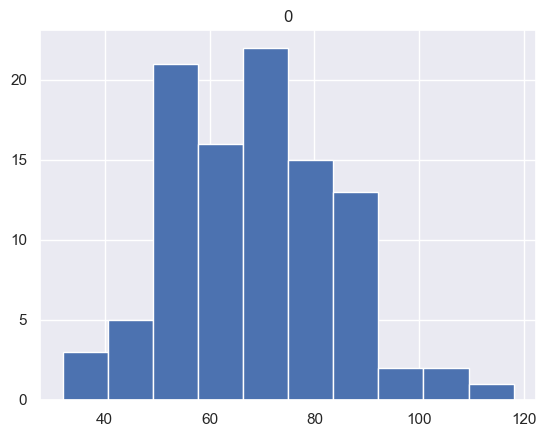

In [22]:
df2.hist()

Most of the median speeds lie between the range from 50-90, and arguably a normal curve with some skew to the left.

**f)** Calculate summary statistics for your sampling distribution, including at least the mean and standard deviation.

In [23]:
df2.describe()

,0
count,100.000000
mean,68.410000
std,15.606975
min,32.000000
25%,57.250000
50%,67.750000
75%,80.000000
max,118.000000


## 2. [4 points] Considering a Rule Change

Suppose that you are a data scientist working with Pokemon.  The team is considering updating the game rules so that a different number of Pokemon are allowed to be used in battle.  They would like to explore how the statistic identified in **1b** will vary with these different sample sizes.

You have been tasked with presenting this information to the team to use in determining any changes in rules.

**a)** First, identify at least 3 different number of Pokemon to be used in battle that you will explore.  Be sure that your numbers are fairly different from each other, so that the difference between the smallest number and the largest number are at least 30.

In [37]:
df.sample(5)

,No,Branch_Code,Original_Name,Name,Generation,Height,Weight,Type1,Type2,Ability1,...,SP_Attack,SP_Defense,Speed,Total,E_HP,E_Attack,E_Defense,E_SP_Attack,E_SP_Defense,E_Speed
683,561,561_0,Sigilyph,Sigilyph,5,1.4,14.0,Psychic,Flying,Wonder Skin,...,103,80,97,490,0,0,0,2,0,0
195,147,147_0,Dratini,Dratini,1,1.8,3.3,Dragon,NaN,Shed Skin,...,50,50,50,300,0,1,0,0,0,0
354,286,286_0,Breloom,Breloom,3,1.2,39.2,Grass,Fighting,Effect Spore,...,60,60,70,460,0,2,0,0,0,0
802,664,664_0,Scatterbug,Scatterbug,6,0.3,2.5,Bug,NaN,Shield Dust,...,27,25,35,200,0,0,1,0,0,0
1161,973,973_0,Flamigo,Flamigo,9,1.6,37.0,Flying,Fighting,Scrappy,...,75,64,90,500,0,2,0,0,0,0


Dratini(50), Sigilyph(97), Scatterbug(35)

**b)** Repeat the process from **1d** for the 3 numbers for Pokemon to be allowed in battle that you selected in **2a**.

In [24]:
n_repetitions = 100

median_speeds = []

choices = [20, 100, 60]

for i in range(n_repetitions):
    poke = random.randint(1, 10)
    sample = df.sample(n=6)
    median_speed = sample['Speed'].median()
    median_speeds.append(median_speed)

df2 = pd.DataFrame(median_speeds)
df2

,No,Branch_Code,Original_Name,Name,Generation,Height,Weight,Type1,Type2,Ability1,...,SP_Attack,SP_Defense,Speed,Total,E_HP,E_Attack,E_Defense,E_SP_Attack,E_SP_Defense,E_Speed
74,57,57_0,Primeape,Primeape,1,1.0,32.0,Fighting,NaN,Vital Spirit,...,60,70,95,455,0,2,0,0,0,0
1167,978,978_1,Tatsugiri,Tatsugiri Droopy Form,9,0.3,8.0,Dragon,Water,Commander,...,120,95,82,475,0,0,0,2,0,0
851,709,709_0,Trevenant,Trevenant,6,1.5,71.0,Ghost,Grass,Natural Cure,...,65,82,56,474,0,2,0,0,0,0
147,110,110_1,Weezing,Galarian Weezing,8,3.0,16.0,Poison,Fairy,Levitate,...,85,70,60,490,0,0,2,0,0,0
279,220,220_0,Swinub,Swinub,2,0.4,6.5,Ice,Ground,Oblivious,...,30,30,50,250,0,1,0,0,0,0


**c)** Calculate summary statistics for each of your additional sampling distributions, including at least the mean and standard deviation.  Compare these values to those from **1f**.

**d)** Describe how your sampling distributions from **2b** and **1d** change as the number of Pokemon allowed in battle increases.